## 1. Setup and Environment Configuration

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Set high-resolution plotting aesthetics matching academic publication standards
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["savefig.dpi"] = 300
print("Environment setup complete. Ready to evaluate.")

# Define a generic output directory
output_dir = "output"
os.makedirs(output_dir, exist_ok=True)

Environment setup complete. Ready to evaluate.


## 2. Execute Evaluations via Optimized Parallel Pipeline

We run the evaluation across four critical test configurations. Each execution saves its raw displacement error metrics as `temp_errors.npy`, which we rename to prevent overwrites.

In [3]:
# Configuration 1: Proposed System (Height Filter Enabled, Combined Features)
print("Evaluating Configuration 1/4: Proposed System...")
!python unified_evaluation_pipeline.py --mode evaluate --feature combined

temp_file = "temp_errors.npy"
target_file = os.path.join(output_dir, "errors_hf.npy")

if os.path.exists(temp_file):
    if os.path.exists(target_file): 
        os.remove(target_file)
    os.rename(temp_file, target_file)
    print(f"✓ Moved results to: {target_file}")
else:
    print(f"Error: {temp_file} not generated. Verify unified_evaluation_pipeline.py.")

Evaluating Configuration 1/4: Proposed System...

=== Evaluation / Prediction ===
Preloading DEM matching generator specifications...
Preloading database tiers...
Launching parallel matching executor across available CPU cores...
Matching: 100%|██████████████████████████████| 300/300 [13:36<00:00,  2.72s/it]

GEOMETRIC LOCALIZATION PRECISION BREAKDOWN (Total: 300 samples)
------------------------------------------------------------
Failed Sample IDs (Error > 1km): ['104', '13', '152', '159', '174', '257', '26', '266', '275', '292', '3', '37', '39', '57', '90', '95']
------------------------------------------------------------
  Top-1 Accuracy at 1000m (Coarse): 94.67%
  Top-1 Accuracy at  500m (Grid):   90.33%
  Top-1 Accuracy at  100m (Local):  84.00%
  Top-1 Accuracy at   10m (Meter):  84.00%
------------------------------------------------------------
  Top-5 Accuracy (1000m):           97.67%
  Median Position Error:            0.0 m


In [4]:
# Configuration 2: Blind Search Baseline (Height Filter Disabled, Combined Features)
print("\nEvaluating Configuration 2/4: Blind Search Baseline...")
!python unified_evaluation_pipeline.py --mode evaluate --feature combined --disable_height_filter

temp_file = "temp_errors.npy"
target_file = os.path.join(output_dir, "errors_blind.npy")

if os.path.exists(temp_file):
    if os.path.exists(target_file): 
        os.remove(target_file)
    os.rename(temp_file, target_file)
    print(f"✓ Moved results to: {target_file}")
else:
    print(f"Error: {temp_file} not generated. Verify unified_evaluation_pipeline.py.")


Evaluating Configuration 2/4: Blind Search Baseline...

=== Evaluation / Prediction ===
Preloading DEM matching generator specifications...
Preloading database tiers...
Launching parallel matching executor across available CPU cores...
Matching: 100%|██████████████████████████████| 300/300 [14:41<00:00,  2.94s/it]

GEOMETRIC LOCALIZATION PRECISION BREAKDOWN (Total: 300 samples)
------------------------------------------------------------
Failed Sample IDs (Error > 1km): ['104', '13', '132', '152', '159', '174', '238', '241', '248', '257', '26', '266', '275', '292', '299', '3', '37', '39', '57', '81', '9', '90', '95']
------------------------------------------------------------
  Top-1 Accuracy at 1000m (Coarse): 92.33%
  Top-1 Accuracy at  500m (Grid):   87.67%
  Top-1 Accuracy at  100m (Local):  81.67%
  Top-1 Accuracy at   10m (Meter):  81.67%
------------------------------------------------------------
  Top-5 Accuracy (1000m):           97.00%
  Median Position Error:            0

In [5]:
# Configuration 3: Raw Profile Descriptor (Height Filter Enabled)
print("\nEvaluating Configuration 3/4: Raw Profile Descriptor...")
!python unified_evaluation_pipeline.py --mode evaluate --feature profile

temp_file = "temp_errors.npy"
target_file = os.path.join(output_dir, "errors_profile.npy")

if os.path.exists(temp_file):
    if os.path.exists(target_file): 
        os.remove(target_file)
    os.rename(temp_file, target_file)
    print(f"✓ Moved results to: {target_file}")
else:
    print(f"Error: {temp_file} not generated. Verify unified_evaluation_pipeline.py.")


Evaluating Configuration 3/4: Raw Profile Descriptor...

=== Evaluation / Prediction ===
Preloading DEM matching generator specifications...
Preloading database tiers...
Launching parallel matching executor across available CPU cores...
Matching: 100%|██████████████████████████████| 300/300 [08:00<00:00,  1.60s/it]

GEOMETRIC LOCALIZATION PRECISION BREAKDOWN (Total: 300 samples)
------------------------------------------------------------
Failed Sample IDs (Error > 1km): ['0', '104', '123', '13', '138', '156', '159', '174', '178', '19', '196', '204', '222', '231', '237', '241', '250', '257', '26', '266', '275', '292', '3', '37', '39', '43', '49', '57', '71', '80', '90']
------------------------------------------------------------
  Top-1 Accuracy at 1000m (Coarse): 89.67%
  Top-1 Accuracy at  500m (Grid):   80.00%
  Top-1 Accuracy at  100m (Local):  72.33%
  Top-1 Accuracy at   10m (Meter):  72.33%
------------------------------------------------------------
  Top-5 Accuracy (1000m): 

In [6]:
# Configuration 4: Slope/Derivative Descriptor (Height Filter Enabled)
print("\nEvaluating Configuration 4/4: Slope/Derivative Descriptor...")
!python unified_evaluation_pipeline.py --mode evaluate --feature derivative

temp_file = "temp_errors.npy"
target_file = os.path.join(output_dir, "errors_deriv.npy")

if os.path.exists(temp_file):
    if os.path.exists(target_file): 
        os.remove(target_file)
    os.rename(temp_file, target_file)
    print(f"✓ Moved results to: {target_file}")
else:
    print(f"Error: {temp_file} not generated. Verify unified_evaluation_pipeline.py.")

print("\nAll pipeline evaluations complete. Loading results for analysis...")


Evaluating Configuration 4/4: Slope/Derivative Descriptor...

=== Evaluation / Prediction ===
Preloading DEM matching generator specifications...
Preloading database tiers...
Launching parallel matching executor across available CPU cores...
Matching: 100%|██████████████████████████████| 300/300 [09:04<00:00,  1.82s/it]

GEOMETRIC LOCALIZATION PRECISION BREAKDOWN (Total: 300 samples)
------------------------------------------------------------
Failed Sample IDs (Error > 1km): ['104', '13', '152', '174', '238', '257', '26', '266', '270', '275', '292', '3', '37', '39', '57', '90', '95']
------------------------------------------------------------
  Top-1 Accuracy at 1000m (Coarse): 94.33%
  Top-1 Accuracy at  500m (Grid):   90.33%
  Top-1 Accuracy at  100m (Local):  84.33%
  Top-1 Accuracy at   10m (Meter):  84.33%
------------------------------------------------------------
  Top-5 Accuracy (1000m):           97.67%
  Median Position Error:            0.0 m

All pipeline evaluations co

## 3. Generate Analytical Figures

In [7]:
# Load saved error arrays
errors_hf = np.load(os.path.join(output_dir, "errors_hf.npy"))
errors_blind = np.load(os.path.join(output_dir, "errors_blind.npy"))
errors_profile = np.load(os.path.join(output_dir, "errors_profile.npy"))
errors_deriv = np.load(os.path.join(output_dir, "errors_deriv.npy"))

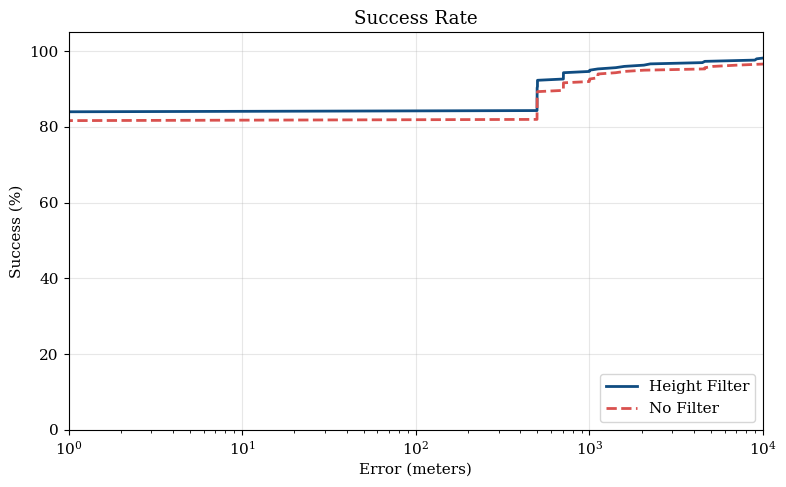

In [13]:
plt.figure(figsize=(8, 5))

def plot_cdf(errors, label, color, linestyle="-"):
    sorted_errors = np.sort(errors)
    cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100
    sorted_errors = np.insert(sorted_errors, 0, 0.0)
    cdf = np.insert(cdf, 0, 0.0)
    plt.plot(sorted_errors, cdf, label=label, color=color, lw=2, linestyle=linestyle)

plot_cdf(errors_hf, "Height Filter", "#0F4C81")
plot_cdf(errors_blind, "No Filter", "#D9514E", "--")

plt.xscale("log")
plt.xlim(1, 10000)
plt.ylim(0, 105)
plt.xlabel("Error (meters)")
plt.ylabel("Success (%)")
plt.title("Success Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("plot_success_rate.png")
plt.show()

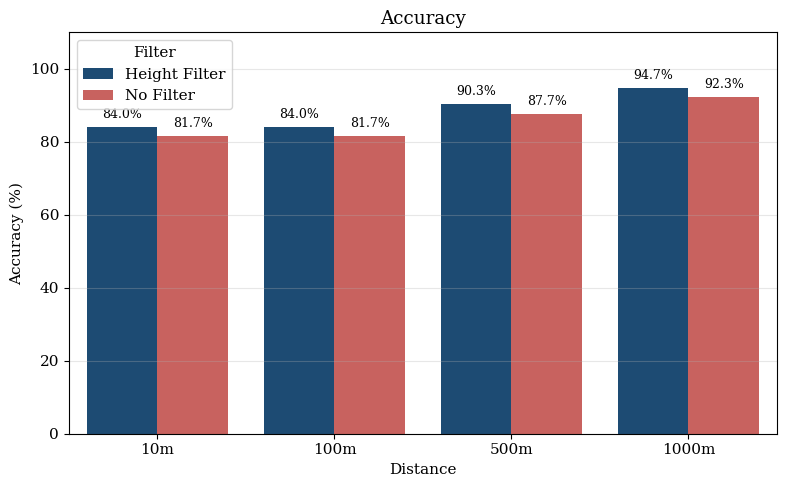

In [14]:
thresholds = [10, 100, 500, 1000]
prec_hf = [np.sum(errors_hf <= t) / len(errors_hf) * 100 for t in thresholds]
prec_blind = [np.sum(errors_blind <= t) / len(errors_blind) * 100 for t in thresholds]

df = pd.DataFrame({
    "Distance": ["10m", "100m", "500m", "1000m"] * 2,
    "Accuracy (%)": prec_hf + prec_blind,
    "Filter": ["Height Filter"] * 4 + ["No Filter"] * 4
})

plt.figure(figsize=(8, 5))
sns.barplot(x="Distance", y="Accuracy (%)", hue="Filter", data=df, palette=["#0F4C81", "#D9514E"])
plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.xlabel("Distance")
plt.title("Accuracy")
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1.5),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.savefig("plot_accuracy.png")
plt.show()

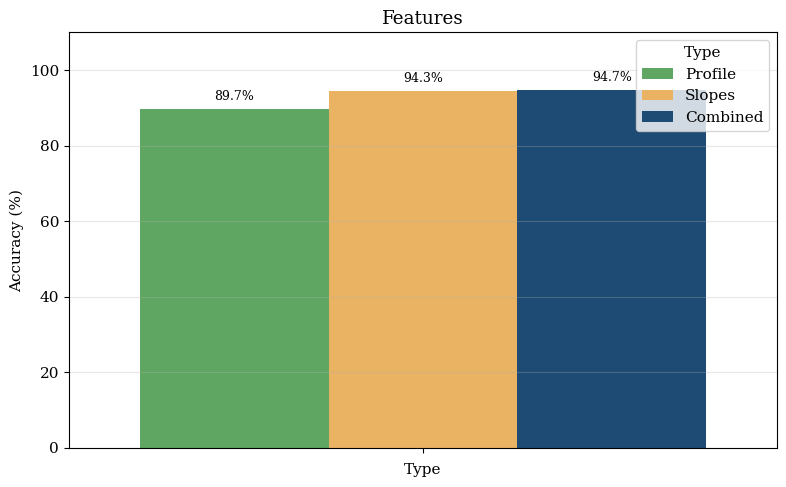

In [19]:
r1_hf = np.sum(errors_hf <= 1000) / len(errors_hf) * 100
r1_profile = np.sum(errors_profile <= 1000) / len(errors_profile) * 100
r1_deriv = np.sum(errors_deriv <= 1000) / len(errors_deriv) * 100

features_df = pd.DataFrame({
    "Type": ["Profile", "Slopes", "Combined"],
    "Accuracy (%)": [r1_profile, r1_deriv, r1_hf]
})

plt.figure(figsize=(8, 5))
sns.barplot(hue="Type", y="Accuracy (%)", data=features_df, palette=["#53B257", "#FFB74D", "#0F4C81"])
plt.ylim(0, 110)
plt.ylabel("Accuracy (%)")
plt.xlabel("Type")
plt.title("Features")
for p in plt.gca().patches:
    if p.get_height() > 0:
        plt.gca().annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() + 1.5),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "plot_features.png"))
plt.show()

### Figure 4: Error Density and Localization Distribution
This density histogram illustrates the distribution of localization errors for our proposed system, highlighting the massive concentration of exact coordinate matches close to 0 meters.

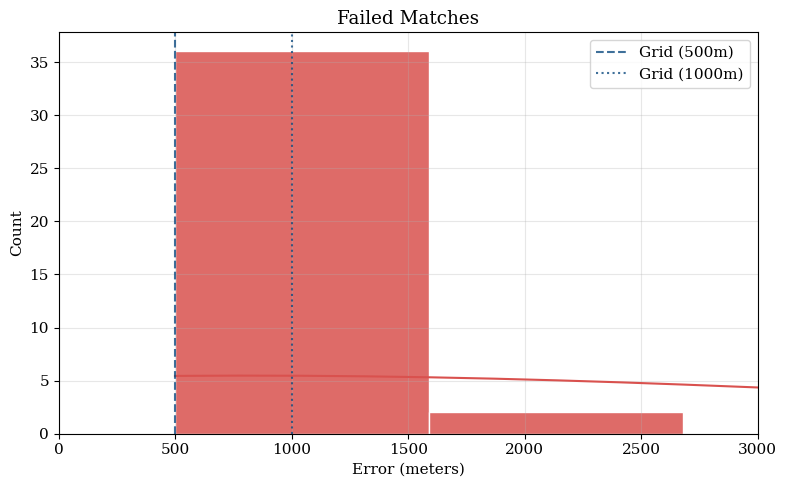

In [20]:
plt.figure(figsize=(8, 5))

failed_errors = errors_hf[errors_hf > 10.0]

sns.histplot(failed_errors, bins=25, kde=True, color="#D9514E", edgecolor="white", alpha=0.85)
plt.axvline(500, color="#0F4C81", linestyle="--", alpha=0.8, label="Grid (500m)")
plt.axvline(1000, color="#0F4C81", linestyle=":", alpha=0.8, label="Grid (1000m)")

plt.xlim(0, 3000)
plt.xlabel("Error (meters)")
plt.ylabel("Count")
plt.title("Failed Matches")
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "plot_failed_matches.png"))
plt.show()

## 4. Academic Summary Table

In [12]:
# Reconstruct the evaluation table dynamically using saved numpy data
summary_data = {
    "Evaluation Metric": [
        "Recall@1 (R@1) / Spatial Accuracy at 1000m", 
        "Spatial Precision at 500m (A@500m)", 
        "Spatial Precision at 100m (A@100m)", 
        "Spatial Precision at 10m (A@10m)",
        "Median Localization Position Error"
    ],
    "Proposed System (Bilinear Altimetric Constraint)": [
        f"{np.sum(errors_hf <= 1000) / len(errors_hf) * 100:.2f}%",
        f"{np.sum(errors_hf <= 500) / len(errors_hf) * 100:.2f}%",
        f"{np.sum(errors_hf <= 100) / len(errors_hf) * 100:.2f}%",
        f"{np.sum(errors_hf <= 10) / len(errors_hf) * 100:.2f}%",
        f"{np.median(errors_hf):.1f} meters"
    ],
    "Blind Search Baseline (Unconstrained)": [
        f"{np.sum(errors_blind <= 1000) / len(errors_blind) * 100:.2f}%",
        f"{np.sum(errors_blind <= 500) / len(errors_blind) * 100:.2f}%",
        f"{np.sum(errors_blind <= 100) / len(errors_blind) * 100:.2f}%",
        f"{np.sum(errors_blind <= 10) / len(errors_blind) * 100:.2f}%",
        f"{np.median(errors_blind):.1f} meters"
    ]
}

pd.DataFrame(summary_data)

,Evaluation Metric,Proposed System (Bilinear Altimetric Constraint),Blind Search Baseline (Unconstrained)
0,Recall@1 (R@1) / Spatial Accuracy at 1000m,94.67%,92.33%
1,Spatial Precision at 500m (A@500m),90.33%,87.67%
2,Spatial Precision at 100m (A@100m),84.00%,81.67%
3,Spatial Precision at 10m (A@10m),84.00%,81.67%
4,Median Localization Position Error,0.0 meters,0.0 meters
